In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        a=1
        # print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
import torch
import torch.nn as nn
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [4]:
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
])

In [5]:
train_data = datasets.ImageFolder(
    "/kaggle/input/datasets/gargrohan/most-most-final-dataset/Datasets/Train",
    transform=transform
)

test_data = datasets.ImageFolder(
    "/kaggle/input/datasets/gargrohan/most-most-final-dataset/Datasets/Test",
    transform=transform
)

train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
test_loader = DataLoader(test_data, batch_size=32)

In [6]:
model = models.resnet18(pretrained=True)

# Modify final layer
model.fc = nn.Linear(model.fc.in_features, 2)

model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 170MB/s] 


In [7]:
for epoch in range(10):
    model.train()
    total_loss = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")


Epoch 1, Loss: 68.0378
Epoch 2, Loss: 44.9943
Epoch 3, Loss: 38.0388
Epoch 4, Loss: 31.9514
Epoch 5, Loss: 26.6172
Epoch 6, Loss: 20.9915
Epoch 7, Loss: 20.2600
Epoch 8, Loss: 14.0957
Epoch 9, Loss: 13.7508
Epoch 10, Loss: 12.5618


In [8]:
torch.save(model.state_dict(), "modelfinal.pth")

In [9]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing import image
from PIL import Image
from IPython.display import display

2026-03-31 16:48:53.991149: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774975734.211656      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774975734.278959      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774975734.825145      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774975734.825168      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774975734.825171      55 computation_placer.cc:177] computation placer alr

1

Prediction: Dirty Road
Confidence: 0.69


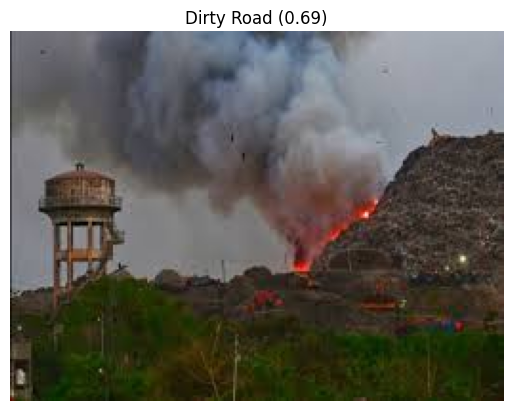

In [10]:
import torch
import torch.nn.functional as F
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt

# -------------------------------
# 1. DEVICE SETUP
# -------------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# -------------------------------
# 2. LOAD MODEL
# -------------------------------
# Make sure your model architecture is already defined before this

model.load_state_dict(torch.load("modelfinal.pth", map_location=device))
model = model.to(device)
model.eval()

# -------------------------------
# 3. CLASS LABELS (VERY IMPORTANT)
# -------------------------------
# Adjust based on your dataset mapping
classes = ["Clean Road", "Dirty Road"]

# -------------------------------
# 4. LOAD IMAGE
# -------------------------------
img_path = "/kaggle/input/datasets/gargrohan/egtg4t4t/delhi ka kude ka pahad.jpg.jpeg"  # 🔁 change if needed

img = Image.open(img_path).convert("RGB")

# -------------------------------
# 5. TRANSFORM
# -------------------------------
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

img_tensor = transform(img).unsqueeze(0).to(device)

# -------------------------------
# 6. PREDICTION
# -------------------------------
with torch.no_grad():
    output = model(img_tensor)              # shape: [1, 2]
    probs = F.softmax(output, dim=1)        # probabilities
    predicted_class = torch.argmax(probs, dim=1).item()
    confidence = probs[0][predicted_class].item()
print(predicted_class)
result = classes[predicted_class]

# -------------------------------
# 7. DISPLAY RESULT
# -------------------------------
plt.imshow(img)
plt.title(f"{result} ({confidence:.2f})")
plt.axis("off")

print(f"\nPrediction: {result}")
print(f"Confidence: {confidence:.2f}")

In [11]:
train_data.class_to_idx

{'Clean': 0, 'Dirty': 1}